# DEIMoS -- Electrical / Power Analysis

The EPS-facing view of a maneuver: what the ADCS *pays* (electrical energy,
peak and average power, battery depth-of-discharge) alongside what it *buys*
(settling time, control effort). Companion to the `power card` that
`deimos run` prints -- same numbers, but as time series and cross-controller
comparisons for the report.

Every budget figure traces to the POWER section of
[`src/deimos/constants.py`](../src/deimos/constants.py) (the single
parameters file): 0.1024 m² of GaAs cells, 39 W peak / 8.5 W orbit-average
generation, a 4.3 W load (2.0 W allocated to ADCS), and the
ASSUMPTION-flagged 40 Wh battery. Change a number there and this whole
notebook follows.

Models are deliberately conservative (`analysis/power.py`): wheel draw is
`integral(sum |g_i·Omega_i|)` with **no regenerative credit** while braking,
and magnetorquer rods are resistive (`P ∝ m²`). A margin shown here is a
real margin.

## 1 -- Setup

In [1]:
import copy
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from deimos import constants
from deimos.sim.config import compose_config
from deimos.sim.runner import simulate
from deimos.analysis.power import power_card, mtq_energy
from deimos.viz.style import BG, FG, GRID, COLORS, WHEEL_CYCLE, CYCLE, _new_fig, _cumtrapz

np.set_printoptions(precision=4, suppress=True)

ADCS_W  = constants.POWER_BUDGET_W["ADCS"]        # 2.0 W allocation
GEN_W   = constants.SOLAR_AVG_POWER_W             # 8.5 W orbit average
BATT_J  = constants.BATTERY_CAPACITY_WH * 3600.0  # 40 Wh -> J  (ASSUMPTION)
print(f"ADCS allocation {ADCS_W} W | orbit-avg generation {GEN_W:.1f} W | battery {constants.BATTERY_CAPACITY_WH:.0f} Wh")

ADCS allocation 2.0 W | orbit-avg generation 8.5 W | battery 40 Wh


## 2 -- Pick a maneuver

Edit and re-run from here. Any scenario/controller pair from `configs/`
works -- the desaturation scenario gets its own section (§6) because its
timescale is ~100x longer.

In [2]:
SCENARIO   = "../configs/scenarios/slew_160_40_30.yaml"
CONTROLLER = "../configs/controllers/wie_eigenaxis.yaml"

cfg = compose_config(SCENARIO, CONTROLLER)
r = simulate(cfg)
print(r.summary())
print(power_card(r))

--- slew_160_40_30 ---
  POINTING
    initial attitude error: 151.66 deg
    settling time (<1 deg): 21.27 s
    final attitude error  : 0.0000 deg
    overshoot             : 0.000 deg
    final |omega|         : 4.273e-09 rad/s
    mean eigenaxis dev.   : 25.95 deg
  ACTUATOR AUTHORITY
    peak |u| commanded    : 1.069e-02 N m
    peak wheel torque     : 4.000e-03 N m (100.0% of 4.0e-03 limit)
    torque saturation     : 2.57% of steps
    speed saturation      : 7.67% of steps
    max wheel speed       : 1258.82 rad/s (12021 rpm)
  COST
    control effort int|u| : 2.9937e-02 N m s
    electrical energy     : 1.5995e+01 J
  VERIFICATION
    max |total momentum|  : 2.313190e-17 kg m^2/s
    total momentum drift  : 2.313e-17 kg m^2/s
    max |q| drift         : 2.220e-16

POWER CARD - slew_160_40_30

GENERATION (constants.py, team EPS sizing)
  solar cell area       : 1024 cm^2 (448 wings + 576 body), GaAs @ 28%
  peak solar power      : 39.0 W
  orbit-average power   : 8.5 W (sunlit 6

## 3 -- Electrical draw vs time

Top: total electrical power (sum of per-wheel |mechanical power|) against
the 2.0 W ADCS allocation and the 8.5 W orbit-average generation. Bottom:
per-wheel breakdown -- an uneven split points at the maneuver loading one
wheel axis harder than the others.

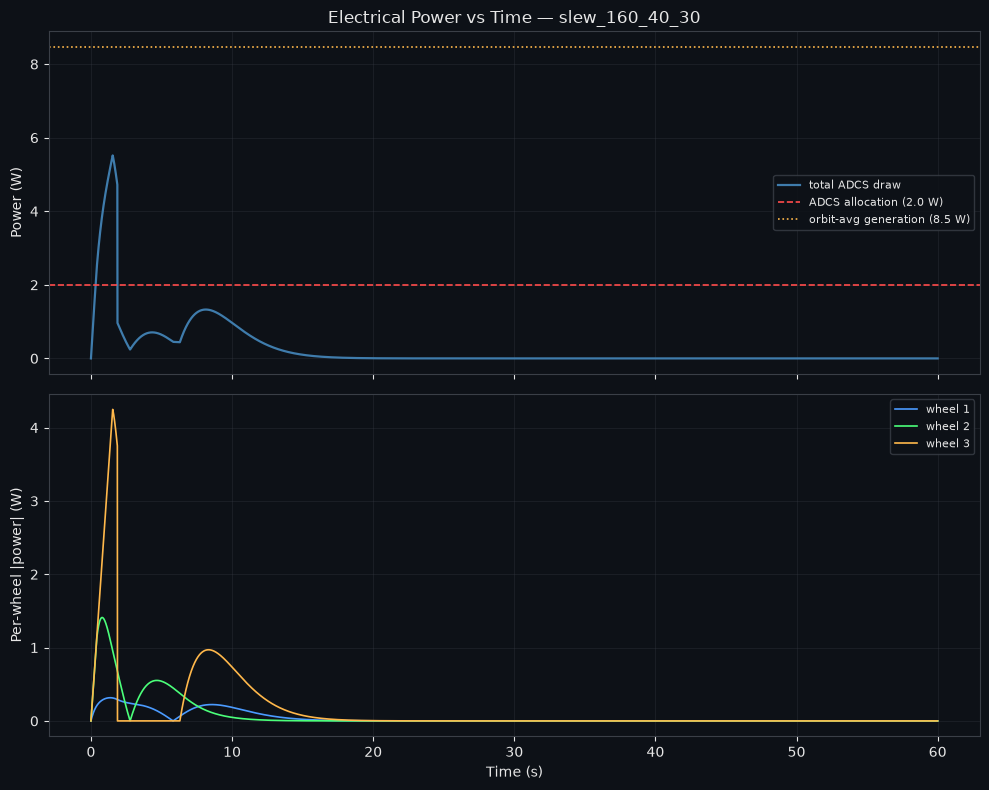

In [3]:
P_wheel = np.abs(r.wheel_power)          # (T, N) per-wheel |power| [W]
P_total = P_wheel.sum(axis=1)

fig, (ax1, ax2) = _new_fig(2)
ax1.plot(r.t, P_total, color=COLORS["main"], linewidth=1.6, label="total ADCS draw")
ax1.axhline(ADCS_W, color="#ff4b4b", linestyle="--", linewidth=1.2,
            label=f"ADCS allocation ({ADCS_W} W)")
ax1.axhline(GEN_W, color="#ffb84b", linestyle=":", linewidth=1.2,
            label=f"orbit-avg generation ({GEN_W:.1f} W)")
ax1.set_ylabel("Power (W)")
ax1.set_title(f"Electrical Power vs Time — {r.name}")
ax1.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8)

for i in range(P_wheel.shape[1]):
    ax2.plot(r.t, P_wheel[:, i], color=WHEEL_CYCLE[i % len(WHEEL_CYCLE)],
             linewidth=1.2, label=f"wheel {i+1}")
ax2.set_ylabel("Per-wheel |power| (W)")
ax2.set_xlabel("Time (s)")
ax2.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8)
fig.tight_layout()
plt.show()

## 4 -- What the effort buys vs what it costs

Cumulative control effort `∫|u| dt` (the control-theory cost) alongside
cumulative electrical energy (the EPS cost), with attitude error for
context. The two costs are *not* proportional: effort is torque-time,
energy is torque-speed-time, so the expensive part of a slew is mid-maneuver
when the wheels are both torquing **and** spinning fast.

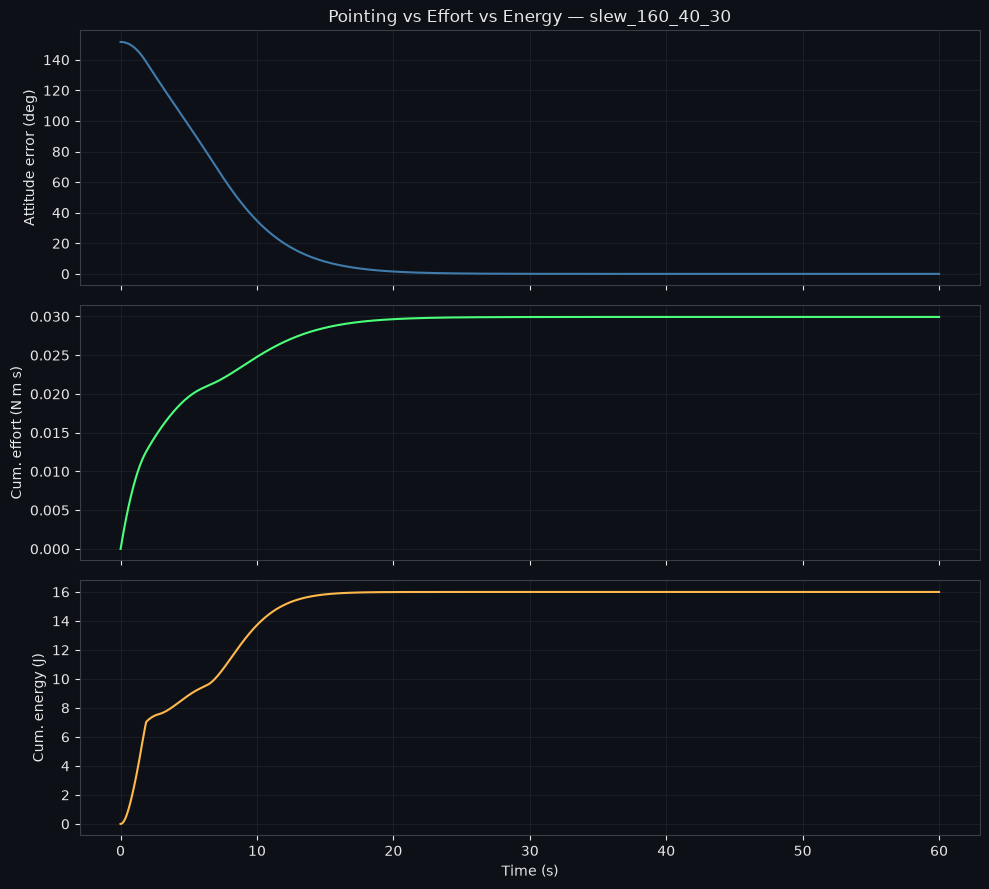

final control effort : 2.9937e-02 N m s
final electrical     : 1.5995e+01 J (4.44e-03 Wh, 0.0111% of battery)


In [4]:
effort_cum = _cumtrapz(np.linalg.norm(r.u, axis=1), r.t)   # N m s
energy_cum = _cumtrapz(P_total, r.t)                        # J

fig, (ax1, ax2, ax3) = _new_fig(3, figsize=(10, 3))
ax1.plot(r.t, r.attitude_error_deg, color=COLORS["main"], linewidth=1.5)
ax1.set_ylabel("Attitude error (deg)")
ax1.set_title(f"Pointing vs Effort vs Energy — {r.name}")

ax2.plot(r.t, effort_cum, color="#4bff7a", linewidth=1.5)
ax2.set_ylabel("Cum. effort (N m s)")

ax3.plot(r.t, energy_cum, color="#ffb84b", linewidth=1.5)
ax3.set_ylabel("Cum. energy (J)")
ax3.set_xlabel("Time (s)")
fig.tight_layout()
plt.show()

print(f"final control effort : {effort_cum[-1]:.4e} N m s")
print(f"final electrical     : {energy_cum[-1]:.4e} J "
      f"({energy_cum[-1] / 3600:.2e} Wh, {100 * energy_cum[-1] / BATT_J:.4f}% of battery)")

## 5 -- Controller comparison: pointing vs power

Every preset on the same scenario, one table -- the columns a report's
trade study wants next to each other. `avg W` is over the run duration;
`DoD` is the battery fraction if the whole maneuver ran in eclipse.

A `never` in the settle column is data, not a bug: `pid_example` is
tuned for disturbance rejection on a hold (Scenario B), and its
integral-heavy gains don't finish a 50° slew inside this run -- the
cheapest energy row buying the worst pointing is exactly the trade
this table exists to expose.

In [5]:
PRESETS = ["wie_eigenaxis", "wie_case3", "pd_aggressive", "pid_example"]

rows = {}
for name in PRESETS:
    c = compose_config(SCENARIO, f"../configs/controllers/{name}.yaml", name=name)
    rr = simulate(c)
    T = rr.t[-1] - rr.t[0]
    E = rr.electrical_energy() + mtq_energy(rr)
    Pavg, Ppk = E / T, np.abs(rr.wheel_power).sum(axis=1).max()
    rows[name] = dict(results=rr, settle=rr.settling_time(), effort=rr.control_effort(),
                      energy=E, avg=Pavg, peak=Ppk, dod=100 * E / BATT_J)

hdr = (f"{'controller':<16}{'settle(s)':>10}{'effort(Nms)':>13}{'energy(J)':>11}"
       f"{'avg(W)':>8}{'peak(W)':>9}{'DoD(%)':>8}  budget")
print(hdr); print("-" * len(hdr))
for name, d in rows.items():
    st = f"{d['settle']:.2f}" if d['settle'] is not None else "never"
    verdict = "OK" if d['avg'] <= ADCS_W else "OVER"
    print(f"{name:<16}{st:>10}{d['effort']:>13.3e}{d['energy']:>11.3e}"
          f"{d['avg']:>8.3f}{d['peak']:>9.3f}{d['dod']:>8.4f}  {verdict}")

controller       settle(s)  effort(Nms)  energy(J)  avg(W)  peak(W)  DoD(%)  budget
-----------------------------------------------------------------------------------
wie_eigenaxis        21.27    2.994e-02  1.600e+01   0.267    5.518  0.0111  OK
wie_case3            22.42    9.230e-02  2.375e+01   0.396    8.555  0.0165  OK
pd_aggressive        18.30    1.637e-01  1.744e+01   0.291    6.867  0.0121  OK
pid_example          17.15    8.289e-02  2.228e+01   0.371    6.871  0.0155  OK


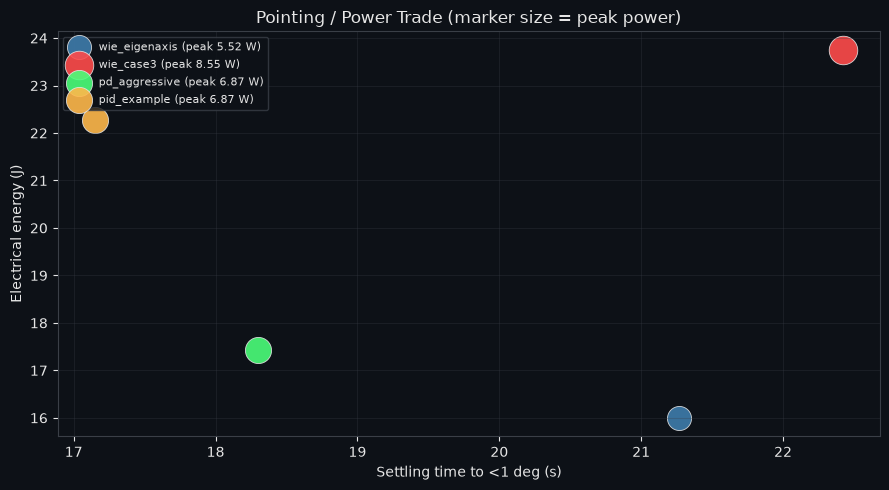

In [6]:
# The trade in one picture: pointing speed vs electrical cost.
# Marker size = peak power (the transient the EPS bus actually has to survive).
fig, (ax,) = _new_fig(1, figsize=(9, 5))
for i, (name, d) in enumerate(rows.items()):
    if d["settle"] is None:
        continue
    ax.scatter(d["settle"], d["energy"], s=80 + 40 * d["peak"],
               color=CYCLE[i % len(CYCLE)], alpha=0.9, edgecolors=FG,
               linewidths=0.6, label=f"{name} (peak {d['peak']:.2f} W)")
ax.set_xlabel("Settling time to <1 deg (s)")
ax.set_ylabel("Electrical energy (J)")
ax.set_title("Pointing / Power Trade (marker size = peak power)")
ax.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8)
fig.tight_layout()
plt.show()

## 6 -- Magnetorquer desaturation energetics (long-timescale)

The desat scenario runs ~50 min of sim time, so it lives in its own cell.
The interesting EPS fact: dumping momentum is cheap -- the three torquer
rods draw a few hundred milliwatts combined (0.2 W/rod at the dipole
limit, ~0.28% of the battery over the full 50 min dump) and the wheels are *braking* (shedding stored kinetic
energy), yet the conservative no-regen model still books the wheel side as
a cost. Set `RUN_DESAT = False` to skip on a quick pass.

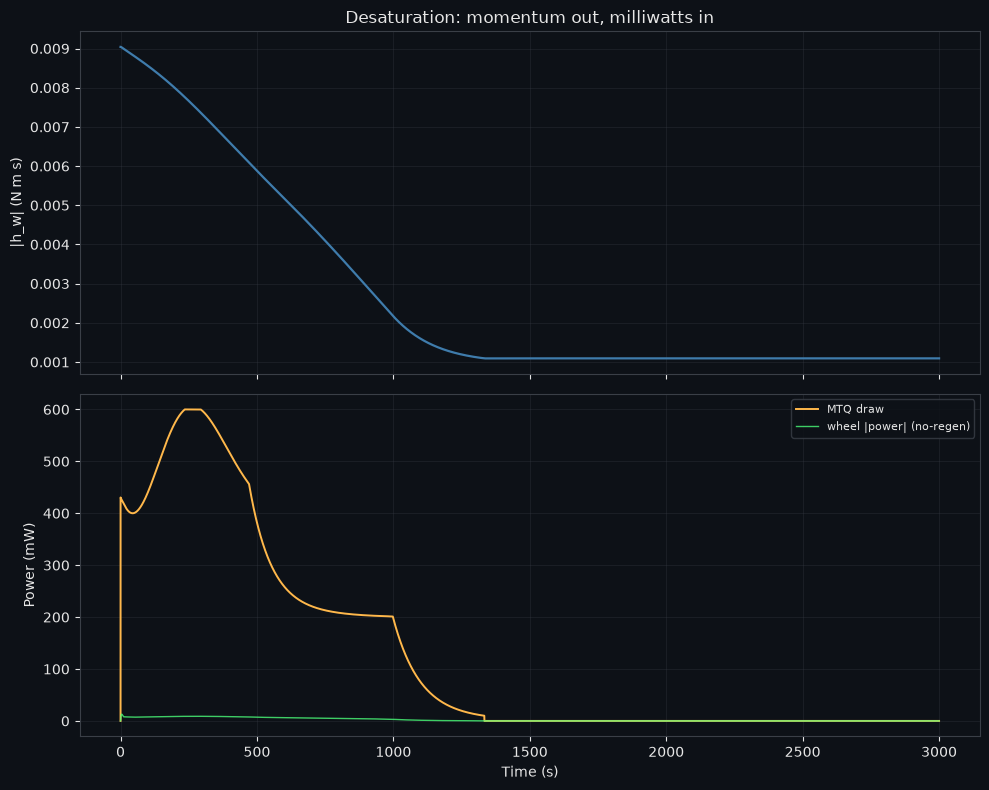

momentum dumped    : 7.948e-03 N m s
magnetorquer energy: 3.908e+02 J   wheel energy: 7.065e+00 J
total              : 3.979e+02 J = 0.2763% of battery over 50 min


In [7]:
RUN_DESAT = True

if RUN_DESAT:
    dcfg = compose_config("../configs/scenarios/desat_recovery.yaml",
                          "../configs/controllers/wie_eigenaxis.yaml", name="desat")
    dr = simulate(dcfg)
    E_wheel, E_mtq = dr.electrical_energy(), mtq_energy(dr)

    P_mtq = constants.MTQ_POWER_W * ((dr.m / constants.MTQ_MAX_DIPOLE) ** 2).sum(axis=1)
    fig, (ax1, ax2) = _new_fig(2)
    ax1.plot(dr.t, dr.wheel_momentum_norm, color=COLORS["main"], linewidth=1.6)
    ax1.set_ylabel("|h_w| (N m s)")
    ax1.set_title("Desaturation: momentum out, milliwatts in")
    ax2.plot(dr.t, P_mtq * 1e3, color="#ffb84b", linewidth=1.4, label="MTQ draw")
    ax2.plot(dr.t, np.abs(dr.wheel_power).sum(axis=1) * 1e3, color="#4bff7a",
             linewidth=1.0, alpha=0.8, label="wheel |power| (no-regen)")
    ax2.set_ylabel("Power (mW)")
    ax2.set_xlabel("Time (s)")
    ax2.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8)
    fig.tight_layout()
    plt.show()

    print(f"momentum dumped    : {dr.momentum_dumped():.3e} N m s")
    print(f"magnetorquer energy: {E_mtq:.3e} J   wheel energy: {E_wheel:.3e} J")
    print(f"total              : {(E_wheel + E_mtq):.3e} J = "
          f"{100 * (E_wheel + E_mtq) / BATT_J:.4f}% of battery over "
          f"{dr.t[-1]/60:.0f} min")

## 7 -- Where this sits in the mission budget

Generation vs the subsystem load stack (constants.py POWER section). The
ADCS bar is the *allocation*; the maneuvers above use a few percent of it
on average -- the allocation is sized for sensor+OBC overhead and worst-case
duty cycles, not one slew.

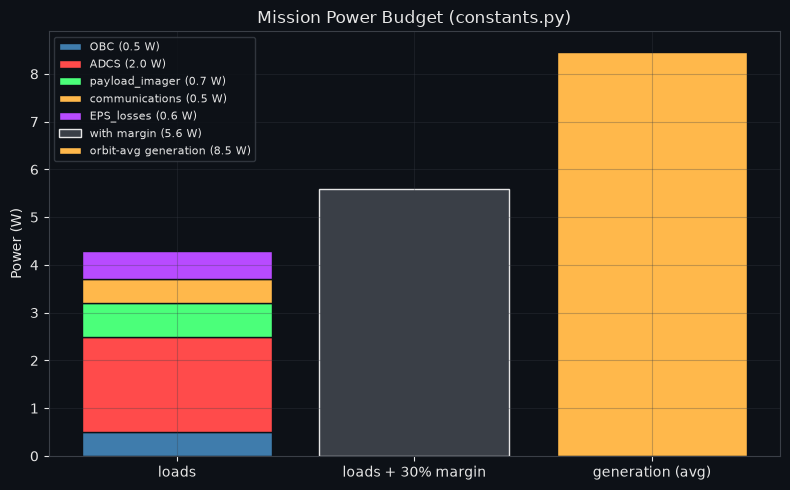

generation / raw load    : 1.97x
generation / margin load : 1.51x


In [8]:
fig, (ax,) = _new_fig(1, figsize=(8, 5))
bottom = 0.0
for i, (name, watts) in enumerate(constants.POWER_BUDGET_W.items()):
    ax.bar("loads", watts, bottom=bottom, color=CYCLE[i % len(CYCLE)],
           edgecolor=BG, label=f"{name} ({watts} W)")
    bottom += watts
ax.bar("loads + 30% margin", constants.POWER_LOAD_WITH_MARGIN_W,
       color="#3a3f47", edgecolor=FG, label=f"with margin ({constants.POWER_LOAD_WITH_MARGIN_W:.1f} W)")
ax.bar("generation (avg)", GEN_W, color="#ffb84b", edgecolor=BG,
       label=f"orbit-avg generation ({GEN_W:.1f} W)")
ax.set_ylabel("Power (W)")
ax.set_title("Mission Power Budget (constants.py)")
ax.legend(facecolor=BG, labelcolor=FG, edgecolor=GRID, fontsize=8)
fig.tight_layout()
plt.show()

print(f"generation / raw load    : {GEN_W / constants.POWER_LOAD_TOTAL_W:.2f}x")
print(f"generation / margin load : {GEN_W / constants.POWER_LOAD_WITH_MARGIN_W:.2f}x")